# Исследование данных о российском кинопрокате



# Описание проекта
Заказчик этого исследования — Министерство культуры Российской Федерации. 
Нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделим внимание фильмам, которые получили государственную поддержку. Попробуем ответить на вопрос, насколько такие фильмы интересны зрителю. 
Будем работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

**Описание данных**
1) Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 
- title — название фильма;
- puNumber — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма;
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма.

Обратите внимание, что столбец budget уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку. 

2) Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах.
- puNumber — номер прокатного удостоверения;
- box_office — сборы в рублях.

Пути к файлам: 
1) /datasets/mkrf_movies.csv — данные о прокатных удостоверениях. 

2) /datasets/mkrf_shows.csv — данные о прокате в российских кинотеатрах. 


## План исследования
**Шаг 1.** Откроем файлы с данными и объединим их в один датафрейм
1.  Объединим данные таким образом, чтобы все объекты из датасета mkrf_movies обязательно вошли в получившийся датафрейм. 
- Пути к файлам: 
- /datasets/mkrf_movies.csv — данные о прокатных удостоверениях. 

- /datasets/mkrf_shows.csv — данные о прокате в российских кинотеатрах. 

**Шаг 2.** Предобработка данных
1. Проверим типы данных в датафрейме и преобразуем там, где это необходимо.
2. Изучим пропуски в датафрейме. Объясним, почему заполнили пропуски определённым образом или почему не стали это делать.
3. Проверим, есть ли в данных дубликаты. Опишем причины, которые могли повлиять на появление дублей.
4. Изучим столбцы, которые содержат категориальные значения:
5. Посмотрим, какая общая проблема встречается почти во всех категориальных столбцах;
6. Исправим проблемные значения в поле type.
7. Изучим столбцы, которые хранят количественные значения. Проверим, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?
8. Добавим новые столбцы:
- Создадим столбец с информацией о годе проката. Выделим год из даты премьеры фильма;
- Создадим два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно;
- Посчитаем, какую долю от общего бюджета фильма составляет государственная поддержка.

**Шаг 3.** Проведем исследовательский анализ данных
1. Посмотрим, сколько фильмов выходило в прокат каждый год. Обратим внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитаем, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируем, как эта доля менялась по годам. Сделаем вывод о том, какой период полнее всего представлен в данных.
2. Изучим, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?
3. С помощью сводной таблицы посчитаем среднюю и медианную сумму сборов для каждого года. Сравним значения и сделаем выводы.Определим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположем, с чем это может быть связано.

**Шаг 4.** Исследуем фильмы, которые получили государственную поддержку
- Поищем интересные закономерности в данных. Посмотрим, сколько выделяют средств на поддержку кино. Проверяем, хорошо ли окупаются такие фильмы, какой у них рейтинг. 

**Шаг 5.** Напишем общий вывод

In [1]:
#импортируем нужные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Откроем файлы с данными и объединим их в один датафрейм. 

Объединим данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм. 

In [2]:
#открываем файл формата CSV нужным методом из библиотеки pandas
mkrf_movies = pd.read_csv("/datasets/mkrf_movies.csv")
mkrf_shows = pd.read_csv("/datasets/mkrf_shows.csv")

In [3]:
#выводим первые пять строк
mkrf_movies.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [4]:
#выводим общую информацию
mkrf_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [5]:
#выводим первые пять строк
mkrf_shows.head()

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [6]:
#выводим общую информацию
mkrf_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


У данных датасетов есть общий столбец puNumber. Но типы данных разные: в датасете mkrf_shows тип данных в данном столбце целочисленный int, а в датасете mkrf_movies это object. Попробуем привести к общему типу данных

При попытке привести mkrf_movies['puNumber'] к типу данных int, видим ошибку: ValueError: invalid literal for int() with base 10: 'нет'. Она нам говорит о том, что в данных присутствует значение, которое мешает перевести все в целочисленный тип. Это значение "нет". Пока не будем трогать. Попробуем привести к типу str

In [7]:
mkrf_shows['puNumber'] = mkrf_shows['puNumber'].astype(str)

Отлично, мы смогли привести к одному типу и теперь можем объединить датасеты в один датафрейм

In [8]:
#соединяем и сохраняем в переменную data
data = mkrf_movies.merge(mkrf_shows, on='puNumber', how='left')
#выведем общую информацию
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

Так как необходимо, чтобы все данные из датасета mkrf_movies обязательно вошли в получившийся датафрейм, нужно провести проверку

In [9]:
#создадим пустой список
cop_mkrf_movies = []
#сделаем цикл, который будет проверять вхождение каждого столбца mkrf_movies в датафрейм data:
for i in mkrf_movies:
    if i in data:
        cop_mkrf_movies.append(i)
    else:
        print("проверка не пройдена")
#выведем список столбцов 
print(cop_mkrf_movies)
print(mkrf_movies.columns)
#выведем сравнение по столбцам проверочного списка и списка столбцов mkrf_movies
print(cop_mkrf_movies == mkrf_movies.columns)

['title', 'puNumber', 'show_start_date', 'type', 'film_studio', 'production_country', 'director', 'producer', 'age_restriction', 'refundable_support', 'nonrefundable_support', 'budget', 'financing_source', 'ratings', 'genres']
Index(['title', 'puNumber', 'show_start_date', 'type', 'film_studio',
       'production_country', 'director', 'producer', 'age_restriction',
       'refundable_support', 'nonrefundable_support', 'budget',
       'financing_source', 'ratings', 'genres'],
      dtype='object')
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


Проверка завершена. Все столбцы присутствуют и объединение данных прошло успешно

### Предобработка данных

#### Проверим типы данных

- Проверим типы данных в датафрейме и преобразуем их там, где это необходимо.

In [10]:
#выведем первые 10 строк
data.head(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


In [11]:
#выведем последние 10 строк
data.tail(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
7476,Я свободен,111023019,2019-12-26T12:00:00.000Z,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,0.0,30000000.0,46154000.0,Министерство культуры,5.9,драма,NaN
7477,Тридцать,121038419,2019-12-26T12:00:00.000Z,Художественный,Демнехст ауф видео,Германия,Симона Костова,Джейлан Атаман-Джека,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.3,драма,NaN
7478,(Не)идеальный мужчина,111023119,2019-12-24T12:00:00.000Z,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,М.Бальчюнас (псевдоним М.Вайсберг),"С.Мелькумов, А.Роднянский, М.Вайсберг, Р.Минас...",«12+» - для детей старше 12 лет,40000000.0,60000000.0,150147502.0,Фонд кино,4.5,"комедия,фантастика,мелодрама",NaN
7479,Эколав,111023219,2019-12-26T12:00:00.000Z,Художественный,ВГИК,Россия,Д.Григорьев,ВГИК,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7480,Акрам Хан: Родом из Карри Хауса,126007919,2019-12-23T12:00:00.000Z,Прочие,Свон Филмз,Великобритания,Ник Пойнц,"Поппи Бегум, Ник Пойнц",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,219569.0
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер",NaN
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7485,"Машины песенки. Серия ""Когда цветут кактусы""",124010719,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,6.3,"комедия,вестерн",NaN


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

- в столбце rating находятся вещественные значения, поэтому нужно будет заменить object на float. Но сначала ихбавимся от аномалий и рассмотрим пропуски

- в столбцах title, type, film_studio, production_country, director, producer, age_restriction, financing_source, genres находятся строки, тип данных не будем менять 

- аналогичная ситуация и со столбцами refundable_support, nonrefundable_support, budget, box_office. Они вещественного типа, содержат числа, трогать не будем

- в столбце puNumber находяться целые числа, но они показывают номер прокатного удостоверения, не будем менять тип данных

- в столбце "show_start_date" должен быть формат даты. Исправим это:

In [13]:
#поменяем тип данных:
data["show_start_date"]= pd.to_datetime(data["show_start_date"], format="%Y-%m-%dT%H:%M:%S")
#для проверки выводим общую инфу:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7486 non-null   object             
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7468 non-null   object             
 5   production_country     7484 non-null   object             
 6   director               7477 non-null   object             
 7   producer               6918 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

ВЫВОД: После изучения типов данных с помощью вывода общей информации по датафрейму и последних 10 строк, мы смогли выявить столбцы, которые нуждаются в смене типа: столбец  show_start_date (нужно изменить тип на дату) и столбец ratings(нужно изменить тип на вещественный)

**Изучим данные поподробнее: рассмотрим каждый столбец по отдельности, просмотрим пропущенные значения для столбцов, дубликаты, аномальные значения**

#### Изучим пропуски в датафрейме

- Объясним, почему заполнили пропуски определённым образом или почему не стали этого делать.

Проверим наличие пропусков и их количество в столбцах:

In [14]:
##Выводим количество пропущенных значений для каждого столбца
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                    976
box_office               4328
dtype: int64

Посмотрим долю пропусков и на основании этого сможем принять решение о удалении, замене либо игнорировании пропусков:

1) Пропусков в столбцах refundable_support, nonrefundable_support, budget больше 95%, размах выборки большой, заполнение пропусков может привести к тому, что данные окажутся неактуальными - стоит оставить пропуски без изменений.

2) В столбце financing_source также около 95% доля пропусков. Тоже пока оставим 

3) В столбце genres пропуски составляют 13%. В этом столбце хранится информация о жанре фильма. В будущем нам эта строка пригодится, поменяем пропуски на "нет информации"

In [15]:
data['genres'] = data['genres'].fillna("нет информации")

4) В столбцах director,production_country, producer и film_studio мало пропусков (до 7%),  заменим на строку "нет информации"

In [16]:
data['director'] = data['director'].fillna("нет информации")
data['producer'] = data['producer'].fillna("нет информации")
data['film_studio'] = data['film_studio'].fillna("нет информации")
data['production_country'] = data['production_country'].fillna("нет информации")

5) Пропуски в столбце box_office занимают ~50%, мы не знаем чем их можно заменить, и удалять нельзя(слишком большая доля), поэтому тоже оставим нетронутыми

6) Столбец ratings содержит 12% пропусков. Данный столбец еще пригодится нам в будущем. Менять пропуски на 0 не вариант, так как далее могут исказится результаты: при анализе нужные значения могут попасть в группу с низким рейтингом, хоть это и неправильно. Пока оставим пропуски нетронутыми

In [17]:
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                 0
production_country          0
director                    0
producer                    0
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                      0
box_office               4328
dtype: int64

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7486 non-null   object             
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7486 non-null   object             
 5   production_country     7486 non-null   object             
 6   director               7486 non-null   object             
 7   producer               7486 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

#### Изучим дубликаты в датафрейме
- Проверим, есть ли в данных дубликаты. Опишем причины, которые могли повлиять на появление дублей.

In [19]:
data.duplicated().sum()

0

Просмотрим именно по столбцам:

In [20]:
#Посмотрим наличие явных дубликатов в столбце title :
data['title'].duplicated().sum()

714

Наличие явных дубликатов в столбце установлено. Их 714. Это довольно много. Проверим их по всей строке: возьмем первый наиболее частый фильм: 

In [21]:
#выводим каждое уникальное значение и подсчитаем частоту его встречаемости в списке
data['title'].value_counts()

День святого Валентина_                             5
Не брать живым /По книге Раджива Чандрасекарана/    4
Белоснежка и охотник                                4
Жена путешественника во времени                     4
Начало_                                             4
                                                   ..
Как прогулять школу с пользой                       1
Интерстеллар                                        1
Отель "Артемида"                                    1
Update/Delete (Апдейт/Делит)                        1
Лягушонок Риббит                                    1
Name: title, Length: 6772, dtype: int64

In [22]:
dub_name = data[data["title"] == "День святого Валентина_"]
dub_name

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3902,День святого Валентина_,221083810,2010-07-15 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
3991,День святого Валентина_,221068010,2010-05-14 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4070,День святого Валентина_,121002210,2010-02-03 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
4196,День святого Валентина_,221136210,2010-11-30 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN
5070,День святого Валентина_,221066410,2010-06-01 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Уэйн Райс, Ка...",США,Гарри Маршалл,Сэмюэл Дж.Браун,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,6.7,"мелодрама,комедия",NaN


Можно заметить, что хоть названия и одинаковые, но  дата премьеры фильма и номер прокатного удостоверения у них разные. Разные удостоверения могли быть выданы в разные промежутки времени и под какую-то цель. Считать их дубликатами несовсем корректно. Аналогично и с другими названиями фильмов.

Проверим дубликаты в номерах прокатного удостоверения:

In [23]:
#Посмотрим наличие явных дубликатов в столбце title :
data['puNumber'].duplicated().sum()

2

По количеству их оказалось 2. Посмотрим на них поближе

In [24]:
#выведем уникальные значения с подсчетом количества
data['puNumber'].value_counts()

221054410    2
221154310    2
121014015    1
121010117    1
111020714    1
            ..
221119211    1
121011617    1
126002311    1
124002719    1
121007915    1
Name: puNumber, Length: 7484, dtype: int64

Два дубликата: 221154310 и 221054410. Нужно посмотреть на строки целиком

In [25]:
# выведем срез с номером 221154310
second_pN = data.loc[data["puNumber"] == "221154310"]
second_pN

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4638,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00+00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.0,"мелодрама,комедия",NaN
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.6,"драма,мелодрама,история",NaN


В данном случае это два совершенно разных фильма с характеристикой. Удалять одну из строк нецелесообразно. Заменим один из номеров на 2211543102

In [26]:
rows = (data['puNumber'] == '221154310') & (data['director'] == 'Зенке Вортманн')
data.loc[rows, "puNumber"] = "2211543101"

In [27]:
# выведем срез с номером 221054410
first_pN = data.loc[data["puNumber"] == "221054410"]
first_pN

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.8,"комедия,криминал",NaN


Сравним строки: данные в них идентичны, просто строки написаны по разному: в названии фильма, в столбце film_studio(фио одни и те же, просто во втором случае написаны неправильно). Удалим одну из строк

In [28]:
data = data.drop_duplicates(subset=["puNumber"], keep="first").reset_index(drop=True)
#d = df.drop_duplicates() 
data['puNumber'].value_counts()

121014015    1
114000514    1
111020714    1
114003919    1
121033316    1
            ..
121011617    1
126002311    1
124002719    1
111005418    1
121007915    1
Name: puNumber, Length: 7485, dtype: int64

In [29]:
data[5067:5069]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"комедия,криминал",NaN
5068,Мисс Конгениальность,221054210,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Касл Рок Интертейнмент, Фортис...",США-Австралия,Дональд Петри,Сандра Буллок,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.1,"боевик,комедия,криминал",NaN


В остальных столбцах могут быть явные дубликаты, но это норма: например тип, страны и тд могут повторяться, это нельзя считать дубликатом 

Рассмотрим категориальные и количественные значения на присутствие неявных дубликатов

#### Изучим категориальные значения

- Посмотрим, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправим проблемные значения в поле `type`.

1) Столбец type

In [30]:
#выведем уникальные значения 
data['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

значения 'Художественный' и ' Художественный'- это одно и то же, но из-за пробела во втором они считаются раздельно. Аналогично и с 'Анимационный' и ' Анимационный'. Уберем пробел и тем самым исправим проблемные значения в поле type

In [31]:
#уберем пробел и перезапишем столбце
data['type'] = data['type'].str.strip()
#выведем уникальные значения для проверки
data['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', 'Музыкально-развлекательный'], dtype=object)

2) Столбец production_country

In [32]:
#выведем уникальные значения 
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия-Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Новая Зеландия',
       'Канада - Франция - Испания', 'США-Германия',
       'США - Великобритания', 'Великобритания', 'США - Германия',
       'Франция - Мексика - США', 'Россия, Казахстан, США',
       'СССР, Швеция', 'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания-США-Германия-КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США - Франция', 'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США-Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия-Великобритания-Германия', 'Чехия', 'США-Австралия',
       'СССР, Финляндия', 'США-Франция-Великобритания-Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
       'Люксембург - Нидерл

Можем заметить что некоторые группы стран пишутся через " - ", другие или через "-", или через запятые с пробелом/без пробела. 

In [33]:
#поочередно заменим всё и приведем  к ", ":
data['production_country'] = data['production_country'].str.replace(" - ", "-")
data['production_country'] = data['production_country'].str.replace("-", ', ')
data['production_country'] = data['production_country'].str.replace(" , ", ', ')
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия, Великобритания', 'Великобритания, Италия',
       'Чехословакия', 'США, Франция, Турция', 'Новая Зеландия',
       'Канада, Франция, Испания', 'США, Германия', 'США, Великобритания',
       'Великобритания', 'Франция, Мексика, США',
       'Россия, Казахстан, США', 'СССР, Швеция',
       'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания, США, Германия, КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США, Франция', 'США, Япония, Франция, Великобритания',
       'Гонконг, Сингапур, Таиланд, Великобритания', 'США, Канада',
       'Франция, Италия, Великобритания, США', 'Франция, США',
       'Ирландия, Великобритания, Германия', 'Чехия', 'США, Австралия',
       'СССР, Финляндия', 'США, Франция, Великобритания, Австрия',
       'США, Бельгия', 'США, Ирландия, Великобритания',
       'Великобритания, США',
       'Люксембург, Нидерланды, Испания, Великобритания,

3) Столбец genres

In [34]:
#выведем уникальные значения 
data['genres'].unique()

array(['боевик,драма,мелодрама', 'драма,военный',
       'фантастика,боевик,триллер', 'драма', 'мелодрама,комедия',
       'мюзикл,мелодрама,комедия', 'комедия,криминал',
       'боевик,триллер,детектив', 'боевик,драма,приключения',
       'драма,спорт', 'триллер,драма,мелодрама', 'комедия,мелодрама',
       'драма,мелодрама,комедия', 'драма,мелодрама', 'драма,история',
       'драма,мелодрама,семейный', 'комедия,мелодрама,криминал',
       'комедия', 'боевик,драма,криминал', 'драма,комедия',
       'ужасы,фантастика,комедия', 'мультфильм,короткометражка,мелодрама',
       'драма,криминал', 'мультфильм,фантастика,фэнтези',
       'триллер,драма,криминал', 'драма,мелодрама,биография',
       'драма,комедия,военный', 'фантастика,драма,детектив',
       'мюзикл,семейный', 'нет информации', 'военный,приключения,драма',
       'документальный,драма', 'драма,биография,история',
       'боевик,триллер,драма', 'фэнтези,боевик',
       'боевик,комедия,криминал', 'мюзикл,комедия,детский',
      

В данном столбце не обнаружено проблем

Вывод: во многих категориальных столбцах большое количество уникальных значений(их наличие можно обьяснить тем, что у нас в этих данных присутсвует перечисление признаков): встречаются проблемы с пробелами или символами, разделяющими значения. Если их привести к общему виду, мы тем самым избавиться от избытка уникальных значений, разных оформлений

4) Столбец ratings показывает рейтинги, проверим, какие значения в нем присутствуют

In [35]:
# выведем уникальные значения столбца
data["ratings"].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

Аномальными можно считать значения, написанные в виде процента. Их мало и можно от них избавиться

In [36]:
#избавимся от аномальных значений
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')
#для проверки выведем уникальные значения
data["ratings"].unique()

array([7.2, 6.6, 6.8, 7.7, 8.3, 8. , 7.8, 8.1, 7.1, 6. , 7.4, 5.8, 8.7,
       6.3, 6.9, 5. , 4.3, 7.3, 7. , 6.4, nan, 8.2, 7.5, 6.7, 7.9, 5.9,
       6.2, 5.6, 6.5, 2.4, 7.6, 6.1, 8.6, 8.5, 8.8, 5.5, 5.1, 5.7, 5.4,
       4.4, 4.5, 5.3, 4.1, 8.4, 2.6, 3.8, 4.6, 4.8, 4. , 3. , 1.6, 4.2,
       5.2, 4.7, 4.9, 3.9, 2.7, 3.3, 2.9, 3.7, 1.4, 3.1, 3.5, 3.2, 2.8,
       1.5, 2.1, 2.5, 9.2, 3.4, 1.1, 3.6, 1. , 1.3, 1.9, 1.8, 1.2, 1.7,
       9. , 8.9, 9.1])

Поменяем тип данных на float

In [37]:
data['ratings'].astype(float)

0       7.2
1       6.6
2       6.8
3       6.8
4       6.8
       ... 
7480    NaN
7481    5.4
7482    NaN
7483    NaN
7484    6.3
Name: ratings, Length: 7485, dtype: float64

5) Столбец puNumber

Рассмотрим строку с найденным ранее значением "нет"

In [38]:
#выведем строку со значением "нет" в столбце 
data[data["puNumber"] == "нет"]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1797,Курбан-роман. (История с жертвой),нет,2014-05-15 12:00:00+00:00,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,нет информации,NaN


Ее стоит удалить(большинство данных в этой строке, которые нам могли в будущем пригодится, отсутствуют(рейтинг,  общий бюджет фильма, объём невозвратных  и возвратных средств государственной поддержки, жанр)

In [39]:
#удалим строку, при этом создадим новую и удалим старую индексацию
data = data.drop(axis=0, index=1797).reset_index(drop=True)
#проверим индексацию
data.loc[1796:1799]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1796,Букашки. Приключение в Долине Муравьев,124001414,2014-04-29 12:00:00+00:00,Анимационный,"Антре Шьен э Лу, Футурикон, Нозон",Франция,"Хелен Жиро, Томас Забо","Филипп Делару, Себастьен Деллуа",«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,7.1,"мультфильм,приключения,семейный",2260.0
1797,12 месяцев,111003613,2013-08-23 12:00:00+00:00,Художественный,"ООО Производственная компания ""ГофроПак"", ООО ...",Россия,А.Баршак,"М.Боев, Л.Могилевский, А.Калинкин, В.Пономаренко",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,4.9,комедия,10745.0
1798,ИУДА,111004013,2013-09-09 12:00:00+00:00,Художественный,"ООО ""АБС""",Россия,А.Богатырев,Е.Белова,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,6.3,"биография,драма,история",NaN
1799,Опасная иллюзия,121000414,2014-01-17 12:00:00+00:00,Художественный,"МедиаПро Пикчерз, Бона Файд Продакшнз","Румыния, США",Фредерик Бонд,"Альберт Бергер, Крэйг Дж. Флорес, Уильям Хорберг",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"триллер,криминал,боевик",1070.0


#### Проверим количественные значения

- Проверим, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?


In [40]:
data.loc[data['refundable_support'] + data['nonrefundable_support'] >= data['budget']]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2052,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,0.0,23000000.0,0.0,"Министерство культуры, Фонд кино",6.6,мелодрама,1.023402e+07
2057,Дуxless 2,111000415,2015-01-26 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,75000000.0,0.0,Фонд кино,6.6,драма,4.461635e+08
2471,Воин (2015),111017315,2015-09-28 12:00:00+00:00,Художественный,"ООО ""Форпост Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,А.Андрианов,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,10000000.0,70000000.0,0.0,Фонд кино,7.8,"боевик,драма,криминал",1.965724e+08
2531,Бармен.,111009615,2015-05-26 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,20000000.0,0.0,0.0,Фонд кино,6.2,"комедия,фэнтези",6.741897e+07
2614,Савва. Сердце воина,114001715,2015-07-21 12:00:00+00:00,Анимационный,"ООО ""Глюкоза Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,М.Фадеев,А.Чистяков,«6+» - для детей старше 6 лет,60000000.0,100000000.0,0.0,Фонд кино,4.6,"мультфильм,приключения,фэнтези",1.844876e+08
2683,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,0.0,59000000.0,0.0,Фонд кино,6.3,"комедия,драма",1.957739e+06
2787,Срочно выйду замуж,111017115,2015-09-30 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,0.0,35000000.0,0.0,Фонд кино,5.1,"комедия,мелодрама",7.293778e+07
2873,Помню - не помню!,111004916,2016-03-01 12:00:00+00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",«12+» - для детей старше 12 лет,0.0,6000000.0,0.0,Министерство культуры,4.3,комедия,1.536293e+07
3046,Любовь с ограничениями,111008216,2016-04-29 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Тюрин,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,19000000.0,51000000.0,0.0,Фонд кино,6.3,"комедия,мелодрама",7.029905e+07
3564,Притяжение (2016),111018116,2016-12-16 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,0.0,250000000.0,0.0,Фонд кино,5.6,фантастика,1.038321e+09


Эти строки противоречат описанию наших данных. Поле бюджета должно как минимум содержать значения с государственной поддержкой. Следовательно в этих строках есть какая-то ошибка и данные по бюджету некорректные. Эти строки можно либо удалить, либо поменять информацию о гос.поддержке(при анализе этой части чтобы не учитывать), либо не трогать. Правильнее будет удалить: по другим фильмам мы не видим примеров того, что бюджет состоит полностью из гос.поддержки, поэтому можно сделать вывод, что какая то часть бюджета была утеряна.

In [41]:
data = data.loc[~(data['refundable_support'] + data['nonrefundable_support'] >= data['budget'])]
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7467 entries, 0 to 7483
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7467 non-null   object             
 1   puNumber               7467 non-null   object             
 2   show_start_date        7467 non-null   datetime64[ns, UTC]
 3   type                   7467 non-null   object             
 4   film_studio            7467 non-null   object             
 5   production_country     7467 non-null   object             
 6   director               7467 non-null   object             
 7   producer               7467 non-null   object             
 8   age_restriction        7467 non-null   object             
 9   refundable_support     315 non-null    float64            
 10  nonrefundable_support  315 non-null    float64            
 11  budget                 315 non-null    float64          

**ВЫВОД: Мы избавились от пропусков в столбцах, от неявных дубликатов и поменяли типы данных. В таком виде данные пригодны для анализа. Но сначала надо внести дополнительную информацию.**

#### Добавим новые столбцы

- Создадим столбец с информацией о годе проката. Выделим год из даты премьеры фильма.

In [42]:
#отделим год из даты премьеры и сохраним в новый столбец
data['year_rent_muvie'] = data['show_start_date'].dt.year
data['year_rent_muvie']

0       2015
1       2016
2       2016
3       2016
4       2015
        ... 
7479    2019
7480    2019
7481    2019
7482    2019
7483    2019
Name: year_rent_muvie, Length: 7467, dtype: int64

- Создадим два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

In [43]:
#создадим ф-цию для вывода первых значений до запятой
def fio_dir_gen(row):
    first_value = row.split(",")
    return first_value[0]
#применим ее к нужным столбцам и сохраним в новых столбцах
data['fio_dir'] = data['director'].apply(fio_dir_gen)
data['first_gen'] = data['genres'].apply(fio_dir_gen)
#выведем новый столбец с именем и фамилией главного режиссёра
data['fio_dir']

0           Кевин Костнер
1               Е.Матвеев
2       Тимур Бекмамбетов
3       Тимур Бекмамбетов
4       Тимур Бекмамбетов
              ...        
7479          Фил Грабски
7480           Ник Пауэлл
7481     Чарльз Е.Бастьен
7482             А.Беляев
7483             И.Трусов
Name: fio_dir, Length: 7467, dtype: object

In [44]:
#выведем новый столбец с основным жанром фильма
data['first_gen']

0               боевик
1                драма
2           фантастика
3           фантастика
4           фантастика
             ...      
7479    нет информации
7480            боевик
7481    нет информации
7482    нет информации
7483           комедия
Name: first_gen, Length: 7467, dtype: object

- Посчитаем, какую долю от общего бюджета фильма составляет государственная поддержка.

In [45]:
#посчитаем долю, округлим до 3 значений после запятой, сохраним в новый столбец
data['share_gov_sup'] = ((data['refundable_support'] + data['nonrefundable_support']) / data['budget']).round(3)
#выведем, отсортировав значения
data['share_gov_sup'].sort_values(ascending=True) 

5598    0.044
3731    0.066
7169    0.077
7178    0.091
3041    0.100
        ...  
7479      NaN
7480      NaN
7481      NaN
7482      NaN
7483      NaN
Name: share_gov_sup, Length: 7467, dtype: float64

ВЫВОД: Мы добавили новые параметры: долю гос.поддержки от общего бюджета фильма , год публикации, столбцы с именем и фамилией главного режиссёра и основным жанром фильма, - получив необходимую информацию из столбцов. Они нам пригодятся далее.

### Проведем исследовательский анализ данных

- Посмотрим, сколько фильмов выходило в прокат каждый год. Данные о прокате в кинотеатрах известны не для всех фильмов. Посчитаем, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируем, как эта доля менялась по годам. Сделаем вывод о том, какой период полнее всего представлен в данных.

In [46]:
#создадим сводную таблицу и сохраним в нее данные: год, количество фильмов в прокате, всего: 
box_of_yes = data.pivot_table(index='year_rent_muvie', values=["box_office", "puNumber"], aggfunc = "count")
#добавим столбец с долей, округлим до сотых
box_of_yes['box_share'] = ((box_of_yes['box_office']/box_of_yes['puNumber'])*100).round(2)
#выведем таблицу
box_of_yes

,box_office,puNumber,box_share
year_rent_muvie,,,
2010,105,984,10.67
2011,109,622,17.52
2012,128,593,21.59
2013,184,630,29.21
2014,278,805,34.53
2015,459,699,65.67
2016,523,815,64.17
2017,355,503,70.58
2018,471,887,53.10


Text(0.5, 1.0, 'Изменение доли прокатных фильмов по годам')

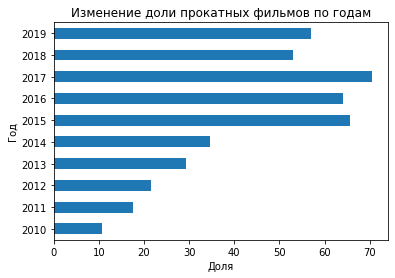

In [47]:
box_of_yes['box_share'].plot(kind="barh")
plt.ylabel('Год')
plt.xlabel('Доля')
plt.title("Изменение доли прокатных фильмов по годам")

Text(0.5, 1.0, 'Изменение доли прокатных фильмов по годам')

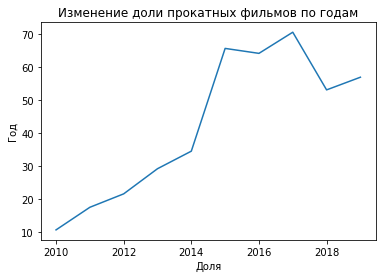

In [48]:
box_of_yes['box_share'].plot()
plt.ylabel('Год')
plt.xlabel('Доля')
plt.title("Изменение доли прокатных фильмов по годам")

Доля фильмов с указанной информацией о прокате в кинотеатрах с 2010 по 2017 увеличивалась. Самая большая доля в 2017, но при этом само количество фильмов в этот год значительно меньше. Далее в 2018 и 2019 она заметно уменьшилась до ~55%, но при этом эти годы содержат больше информации по фильмам и представлены полнее всего. Больше всего фильмов вышло в 2019 году, а меньше всего в 2010. 

- Изучим, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

In [49]:
#создадим сводную таблицу по сумме сборов по годам:
box_of_money = data.pivot_table(index='year_rent_muvie', values="box_office", aggfunc = "sum")
box_of_money

,box_office
year_rent_muvie,
2010,2.428654e+06
2011,1.410276e+07
2012,6.955423e+06
2013,2.979971e+07
2014,7.434718e+09
2015,3.852783e+10
2016,4.674232e+10
2017,4.845815e+10
2018,4.925199e+10


В период с 2010 по 2013 был то рост, то падение. Начиная с 2014 по 2018 только рост сборов, в 2019 небольшое падение по сумме

Выделим годы с максимальной и минимальной суммой сборов

In [50]:
box_of_money.sort_values(by='box_office', ascending=False).head(1)

,box_office
year_rent_muvie,
2018,4.925199e+10


In [51]:
box_of_money.sort_values(by='box_office', ascending=True).head(1)

,box_office
year_rent_muvie,
2010,2428654.0


<AxesSubplot:xlabel='year_rent_muvie'>

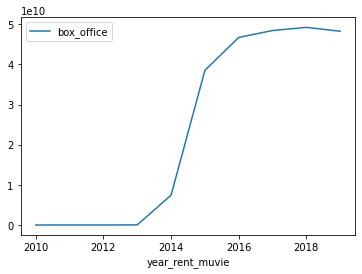

In [52]:
box_of_money.plot()

<AxesSubplot:xlabel='year_rent_muvie', ylabel='box_office'>

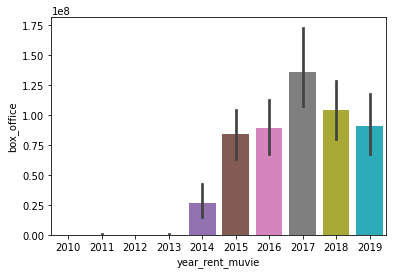

In [53]:
#построим столбчатую диаграмму
sns.barplot(x=data['year_rent_muvie'], y=data['box_office'])

ВЫВОД: Год с максимальной суммой сборов - это 2018, а с минимальной - 2010. В основном с годами в период с 2013 сумма сборов увеличивается, заметны небольшие спады в период с 2010 по 2013 и с 2018 по 2019

- С помощью сводной таблицы посчитаем среднюю и медианную сумму сборов для каждого года.

In [54]:
box_of_options = data.pivot_table(index='year_rent_muvie', values="box_office", aggfunc = ["mean",'median'])
box_of_options.columns=['mean',"median"]
box_of_options

,mean,median
year_rent_muvie,,
2010,2.313004e+04,1700.00
2011,1.293832e+05,3000.00
2012,5.433924e+04,5660.00
2013,1.619549e+05,3522.50
2014,2.674359e+07,18137.50
2015,8.393862e+07,4784781.50
2016,8.937345e+07,3776087.56
2017,1.365018e+08,9919415.00
2018,1.045690e+08,8751895.75


<AxesSubplot:xlabel='year_rent_muvie'>

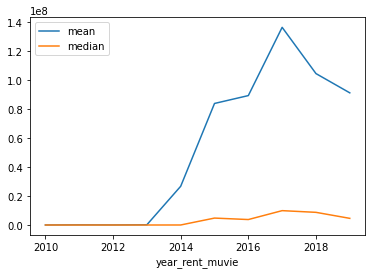

In [55]:
box_of_options.plot()

ВЫВОД: Такие различия между значениями медианы и среднего могут быть вызваны тем, что среднее значение бывает не совсем объективным отражением данных, так как на него могут влиять выбросы(очень большие значения в столбце сборов)

- Определим, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да,то с чем это может быть связано?

In [56]:
#возьмем нужный период:
data['date_year'] = data.loc[data['year_rent_muvie'] > 2014, "year_rent_muvie"]

In [57]:
#сохраним в новой переменной нужные столбцы
data_new = data.loc[:,['date_year', 'age_restriction', 'box_office']]
#создадим сводную таблицу
data_pivot = data_new.pivot_table(index=['date_year','age_restriction'], values='box_office', aggfunc=['sum','count'])
#переименуем столбцы
data_pivot.columns=['sum','count']
data_pivot

sum  count
date_year age_restriction                                            
2015.0    «0+» - для любой зрительской аудитории  3.790546e+08     39
          «12+» - для детей старше 12 лет         1.341951e+10     72
          «16+» - для детей старше 16 лет         1.078160e+10    165
          «18+» - запрещено для детей             5.430351e+09    131
          «6+» - для детей старше 6 лет           8.517312e+09     52
2016.0    «0+» - для любой зрительской аудитории  1.502288e+08     41
          «12+» - для детей старше 12 лет         1.115076e+10     80
          «16+» - для детей старше 16 лет         1.659425e+10    181
          «18+» - запрещено для детей             6.793930e+09    151
          «6+» - для детей старше 6 лет           1.205315e+10     70
2017.0    «0+» - для любой зрительской аудитории  2.295989e+08      3
          «12+» - для детей старше 12 лет         7.851428e+09     41
          «16+» - для детей старше 16 лет         1.869459e+10    120
          «18+» - запрещено для детей             9.651496e+09    147
          «6+» - для детей старше 6 лет           1.203103e+10     44
2018.0    «0+» - для любой зрительской аудитории  3.244900e+07      5
          «12+» - для детей старше 12 лет         1.426729e+10     67
          «16+» - для детей старше 16 лет         1.627841e+10    155
          «18+» - запрещено для детей             8.760086e+09    179
          «6+» - для детей старше 6 лет           9.913759e+09     65
2019.0    «0+» - для любой зрительской аудитории  1.774607e+07      3
          «12+» - для детей старше 12 лет         1.268020e+10     85
          «16+» - для детей старше 16 лет         1.275342e+10    178
          «18+» - запрещено для детей             1.012180e+10    183
          «6+» - для детей старше 6 лет           1.270494e+10     80

Text(0.5, 1.0, 'График суммы сборов по каждой возрастной категории')

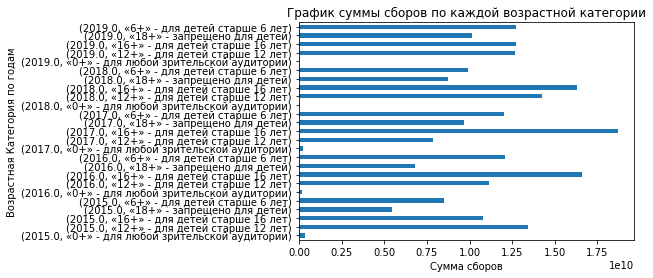

In [58]:
data_pivot['sum'].plot(kind='barh')
plt.xlabel('Сумма сборов')
plt.ylabel('Возрастная Категория по годам')
plt.title("График суммы сборов по каждой возрастной категории" )

Вывод: Фильмы с возрастным ограничением «0+»  в каждом году имели самую низкую сумму сборов. Категория «12+» с 2015 по 2017 падает по сумме, далее наблюдается повышение в 2018 и опять спад в 2019. Фильмы категории «18+» тоже с низкой суммой, но наблюдается рост с годами(ниже всего в 2015, далее возрастает к 2019).Аналогично и с категорией «6+»: в 2015 по 2017 повышается, в 2018 небольшой спад и в 2019 опять на повышение. Категория «16+» по сборам в 2015 занимает второе место, далее с 2016 по 2019 лидирует, фильмы с этим возрастным ограничением собрали больше всего денег в прокате. 

Посмотрим зависимость суммы сбора от возрастной категории по количеству фильмов

Text(0.5, 1.0, 'График количества фильмов по каждой возрастной категории')

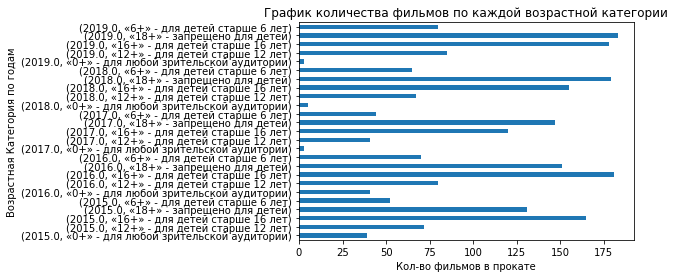

In [59]:
data_pivot['count'].plot(kind='barh')
plt.xlabel('Кол-во фильмов в прокате')
plt.ylabel('Возрастная Категория по годам')
plt.title("График количества фильмов по каждой возрастной категории" )

В 2015 и 2016 по количеству фильмов в прокате лидируют фильмы возврастной категории «16+», в 2017 наблюдается спад, далее опять количество увеличивается. Фильмы категории «0+» имеют самое маленькое количество фильмов в прокате в каждом году. С 2017 лидирует по количеству возрастная группа «18+»

ВЫВОД: В 2015 году по сумме сборов лидирует категория «12+», хоть по количеству прокатных фильмов она уступает другим группам. В 2016 году уже категория «16+» лучшая по показателям как суммы сборов, так и по количеству выпущенных в прокат фильмов. в 2017 и 2018 также «16+» по сумме, но по количеству фильмов уже другая категория - «18+». Что же касается 2019: категории «12+», «6+» и «16+» показывают одинаковый результат по сумме, а по количеству фильмов в прокате лидируют группы «16+» и «18+». Можно заметить как в зависимости от года меняются категории с лучшими результатами по сумме и количеству выпущенных фильмов. Это может быть связано с тем, что в разные годы фильмы определенных категорий по возрасту были актуальнее, чем другие. 

Построим график средних сборов по каждой категории с годами 

Text(0.5, 1.0, 'График сборов по возрастным категориям')

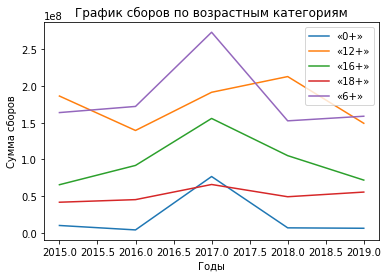

In [60]:
data_pivot_2 = data_new.pivot_table(index='date_year', columns = 'age_restriction', values='box_office', aggfunc="mean")
data_pivot_2.plot()
plt.legend(["«0+»", "«12+»", "«16+»", "«18+»", "«6+»"])
plt.xlabel('Годы')
plt.ylabel('Сумма сборов')
plt.title("График сборов по возрастным категориям" )

Если рассматривать среднюю сумму сборов, то самый лучший по росту сбора для многих категорий был 2017 год.

ВЫВОД: Добавлены новые столбцы, 

### Исследуем фильмы, которые получили государственную поддержку

Поищем интересные закономерности в данных. Посмотрим, сколько выделяют средств на поддержку кино. Проверим, хорошо ли окупаются такие фильмы, какой у них рейтинг.

Рассмотрим поподробнее параметры на наличие выбросов: 
- объём возвратных средств государственной поддержки;
- объём невозвратных средств государственной поддержки;
- общий бюджет фильма
- сборы в рублях

Перед началом сохраним исходное кол-во в отдельную переменную

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7467 entries, 0 to 7483
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7467 non-null   object             
 1   puNumber               7467 non-null   object             
 2   show_start_date        7467 non-null   datetime64[ns, UTC]
 3   type                   7467 non-null   object             
 4   film_studio            7467 non-null   object             
 5   production_country     7467 non-null   object             
 6   director               7467 non-null   object             
 7   producer               7467 non-null   object             
 8   age_restriction        7467 non-null   object             
 9   refundable_support     315 non-null    float64            
 10  nonrefundable_support  315 non-null    float64            
 11  budget                 315 non-null    float64          

In [62]:
data_orig = data.shape[0]
data_orig

7467

**1) Общий бюджет фильма**

In [63]:
#вывод общей информации по числовым характеристикам выборки
data["budget"].describe()

count    3.150000e+02
mean     1.340961e+08
std      1.912260e+08
min      1.446246e+07
25%      4.615387e+07
50%      7.337955e+07
75%      1.500043e+08
max      2.305074e+09
Name: budget, dtype: float64

<AxesSubplot:>

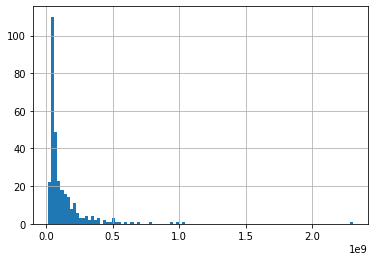

In [64]:
#построим гистограмму 
data["budget"].hist(bins=100)

<AxesSubplot:>

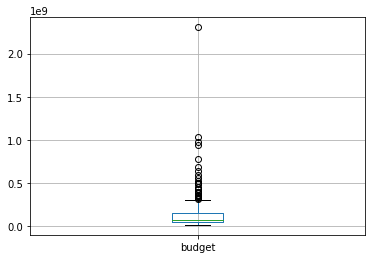

In [65]:
#построим диаграмму размаха
data.boxplot('budget')

В данных много слишком высоких значений: за пределами «усов» находятся выбросы. Они рисуются отдельными точками. По гистограмме видно, что отдельные значения присутствуют еще и на 2.3. Избавимся от выбросов, но при этом будем учитывать, что удаления слишком большого обьема данных может плохо сказаться на анализе в будущем, поэтому будем удалять не более 1% данных

In [66]:
#Уберем выбросы с 2.0 и оставим нужный срез
data = data.loc[(data["budget"] < 2.000074e+09)|(data["budget"].isna())]

**2) Сборы в рублях**

In [67]:
#вывод общей информации по числовым характеристикам выборки
data["box_office"].describe()

count    3.140000e+03
mean     7.592764e+07
std      2.402445e+08
min      0.000000e+00
25%      8.382450e+04
50%      2.280753e+06
75%      2.342549e+07
max      3.073569e+09
Name: box_office, dtype: float64

<AxesSubplot:>

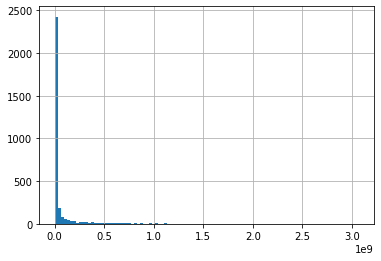

In [68]:
#построим гистограмму 
data["box_office"].hist(bins=100)

<AxesSubplot:>

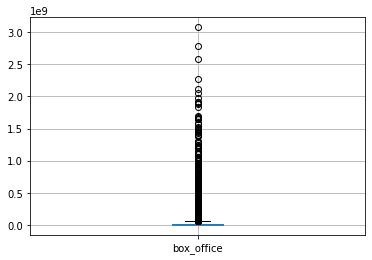

In [69]:
#построим диаграмму размаха
data.boxplot('box_office')

In [70]:
#Уберем выбросы с 2.0 и оставим нужный срез
data = data.loc[(data["box_office"] < 2.003569e+09)&(data["box_office"] > 0)|(data["box_office"].isna())]

**3) Объём возвратных средств государственной поддержки**

In [71]:
#вывод общей информации по числовым характеристикам выборки
data["refundable_support"].describe()

count    3.110000e+02
mean     1.090032e+07
std      2.324257e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+07
max      1.500000e+08
Name: refundable_support, dtype: float64

<AxesSubplot:>

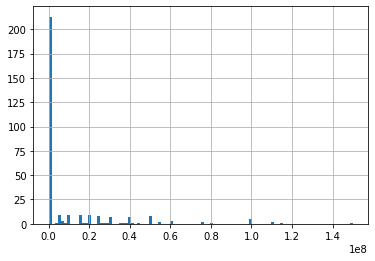

In [72]:
#построим гистограмму 
data["refundable_support"].hist(bins=100)

<AxesSubplot:>

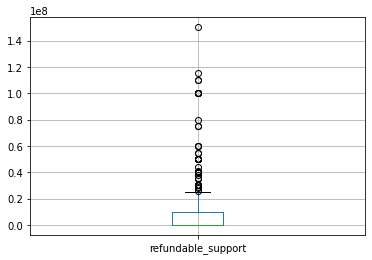

In [73]:
#построим диаграмму размаха
data.boxplot('refundable_support')

In [74]:
#Уберем выбросы с 1.0 и оставим нужный срез
data = data.loc[(data["refundable_support"] < 1.000000e+08)|(data["refundable_support"].isna())]

**4) Объём невозвратных средств государственной поддержки**

In [75]:
#вывод общей информации по числовым характеристикам выборки
data["nonrefundable_support"].describe()

count    3.020000e+02
mean     4.218119e+07
std      4.406863e+07
min      0.000000e+00
25%      2.500000e+07
50%      3.000000e+07
75%      4.000000e+07
max      3.921045e+08
Name: nonrefundable_support, dtype: float64

<AxesSubplot:>

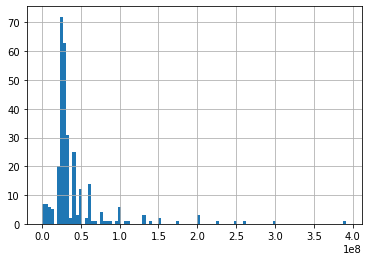

In [76]:
#построим гистограмму 
data["nonrefundable_support"].hist(bins=100)

<AxesSubplot:>

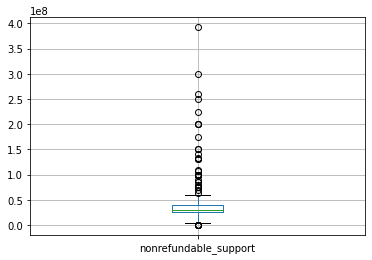

In [77]:
#построим диаграмму размаха
data.boxplot('nonrefundable_support')

In [78]:
#Уберем выбросы с 2.0 и оставим нужный срез
data = data.loc[(data["refundable_support"] < 0.6000000e+08)|(data["refundable_support"].isna())]
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7421 entries, 0 to 7483
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7421 non-null   object             
 1   puNumber               7421 non-null   object             
 2   show_start_date        7421 non-null   datetime64[ns, UTC]
 3   type                   7421 non-null   object             
 4   film_studio            7421 non-null   object             
 5   production_country     7421 non-null   object             
 6   director               7421 non-null   object             
 7   producer               7421 non-null   object             
 8   age_restriction        7421 non-null   object             
 9   refundable_support     296 non-null    float64            
 10  nonrefundable_support  296 non-null    float64            
 11  budget                 296 non-null    float64          

Сравним изначальное количество данных с результатом после фильтрации

In [79]:
cnt_old = data_orig

In [80]:
cnt_new = data.shape[0]

In [81]:
cnt_new * 100 /cnt_old

99.38395607338958

Отлично. В результате очистки данных от выбросов и аномалий нам удалось сохранить более 99% исходных данных.

ВЫВОД: Мы рассмотрели данные, нашли выбросы, сделав для них гистограмму, диаграмму размаха и общую информацию по каждому интересующему столбцу. Аномалии и выбросы могли возникнуть вследвие отсутствия данных, ошибки выгрузки данных. Избавившись от аномалий и выбросов, мы смогли более эффективно очистить данные и теперь можно перейти к поиску решения для нашей задачи

Посмотрим как отличается сумма государственной поддержки у фильмов по жанрам

In [82]:
#создадим копию нашего датафрейма
data_final = data.copy()
#уберем из столбца с жанрами заглушки  
data_final['first_gen'] = data_final.loc[data_final['first_gen'] != "нет информации", "first_gen" ]
#создадим столбец с суммой гос.поддержки
data_final['all_gov_sup'] = data_final['refundable_support'] + data_final['nonrefundable_support']
#сгруппируем данные по жанру и сумме гос.поддержки
data_gov_sup = data_final.groupby(['first_gen']).agg({'all_gov_sup':'sum'})
#отсортируем данные и возьмем только те жанры, у которых сумма больше 0
data_gov_sup = data_gov_sup.sort_values(by='all_gov_sup', ascending = True).tail(20)
data_gov_sup

,all_gov_sup
first_gen,
реальное ТВ,5.300000e+07
спорт,5.500000e+07
мюзикл,1.004531e+08
биография,1.125100e+08
детский,1.190000e+08
история,1.700000e+08
приключения,1.760000e+08
боевик,2.540000e+08
криминал,2.800000e+08


Text(0, 0.5, 'Жанры')

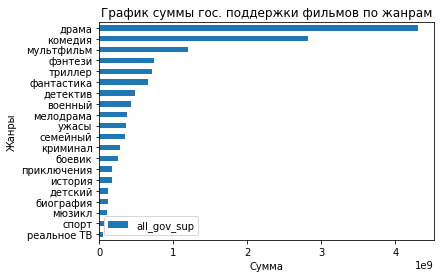

In [83]:
#построим график
data_gov_sup.plot(kind='barh', title="График суммы гос. поддержки фильмов по жанрам" )
plt.xlabel('Сумма')
plt.ylabel('Жанры')

In [84]:
#сгруппируем данные по жанру и доле гос.поддержки
data_gov_sup = data_final.groupby(['first_gen']).agg({'share_gov_sup':'sum'}).round(2)
#отсортируем данные и возьмем только те жанры, у которых доля больше 0
data_gov_sup = data_gov_sup.sort_values(by='share_gov_sup', ascending = True).tail(20)
data_gov_sup

,share_gov_sup
first_gen,
история,0.50
реальное ТВ,0.66
спорт,0.94
биография,1.04
мюзикл,1.34
криминал,1.97
приключения,2.01
боевик,2.20
детектив,2.46


Text(0, 0.5, 'Жанры')

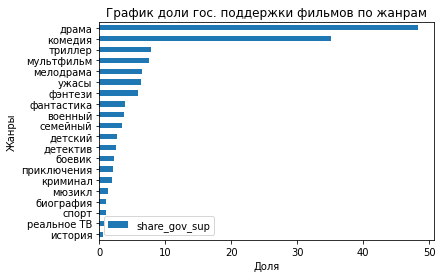

In [85]:
#построим график
data_gov_sup.plot(kind='barh', title="График доли гос. поддержки фильмов по жанрам" )
plt.xlabel('Доля')
plt.ylabel('Жанры')

По результатам можно заметить, что больше всего государственных средств идет на поддержку фильмов жанра "драма". Минимальное по сумме - это жанр "реальное ТВ". Изучим рейтинг фильмов всех жанров 

In [86]:
#создадим сводную таблицу по сумме гос.поддержки и рейтингу фильмов каждого жанра
rating_group = data_final.pivot_table(index='first_gen', values=["all_gov_sup", 'ratings'], aggfunc=["sum", "mean"]).round(2)
#переименнуем столбцы
rating_group.columns=['sum_sup', "sum_ret", "mean_sup", "mean_ret"]
#удалим лишние столбцы
rating_group = rating_group.drop(columns=["sum_ret", "mean_sup"])
#отсортируем таблицу
rating_group = rating_group.sort_values(by='sum_sup', ascending = False).head(20)
rating_group

,sum_sup,mean_ret
first_gen,,
драма,4.309407e+09,6.76
комедия,2.823283e+09,5.99
мультфильм,1.196520e+09,6.27
фэнтези,7.329000e+08,6.57
триллер,7.096453e+08,6.58
фантастика,6.560000e+08,6.61
детектив,4.850000e+08,6.65
военный,4.220009e+08,6.73
мелодрама,3.750000e+08,6.53


<AxesSubplot:xlabel='first_gen'>

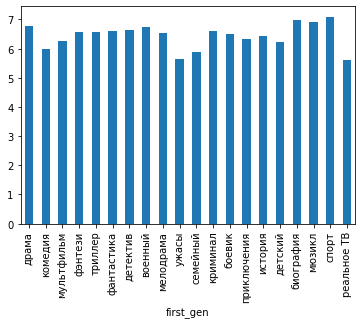

In [87]:
#построим график по рейтингу
rating_group['mean_ret'].plot(kind='bar')

In [88]:
#выведем наибольший по сумме жанр
rating_group.sort_values(by='sum_sup', ascending = False).head(1)

,sum_sup,mean_ret
first_gen,,
драма,4.309407e+09,6.76


In [89]:
#выведем наибольший по рейтингу жанр
rating_group.sort_values(by='sum_sup', ascending = False).tail(1)

,sum_sup,mean_ret
first_gen,,
реальное ТВ,53000000.0,5.6


In [90]:
#выведем наименьший по сумме жанр
rating_group.sort_values(by='mean_ret', ascending = False).head(1)

,sum_sup,mean_ret
first_gen,,
спорт,55000000.0,7.1


In [91]:
#выведем наименьший по рейтингу жанр
rating_group.sort_values(by='mean_ret', ascending = False).tail(1)

,sum_sup,mean_ret
first_gen,,
реальное ТВ,53000000.0,5.6


Вывод по рейтингу: не замечено высоких показателей, связанных с высокой гос. поддержкой: самый большой по сумме жанр- драма с рейтингом ~6.76, самый высокий рейтинг у жанра "спорт". По самой низкой сумме и по самому низкому рейтингу у нас жанр "реальное ТВ" - тут совпадение есть. По данным результатам по рейтингу фильмов жанра "драма" сложно сказать по каким причинам именно этот жанр имеет такую сумму гос.поддержки.

Нужно посмотреть по окупаемости

In [92]:
#создадим столбец с окупаемостью
data['film_payback'] = data['box_office']-data['budget']
#уберем из столбца с жанрами заглушки 
data['first_gen'] = data.loc[data['first_gen'] != "нет информации", "first_gen" ]
#создадим сводную таблицу
paybk_pivot = data.pivot_table(index='first_gen', values=["film_payback", 'ratings'], aggfunc=["sum", "mean"]).round(2)
#переименнуем столбцы
paybk_pivot.columns=['sum_pay', "sum_ret", "mean_pay", "mean_ret"]
#удалим лишние столбцы
paybk_pivot = paybk_pivot.drop(columns=["sum_ret", "mean_pay"])
#отсортируем по убыванию 
paybk_pivot = paybk_pivot.sort_values(by='sum_pay', ascending = False)
paybk_pivot

,sum_pay,mean_ret
first_gen,,
комедия,3.000743e+09,5.99
ужасы,1.462456e+08,5.64
спорт,6.780547e+07,7.10
аниме,0.000000e+00,7.44
музыка,0.000000e+00,7.37
фильм-нуар,0.000000e+00,7.60
вестерн,0.000000e+00,7.30
для взрослых,0.000000e+00,4.47
документальный,0.000000e+00,7.24


Text(0, 0.5, 'Окупаемость')

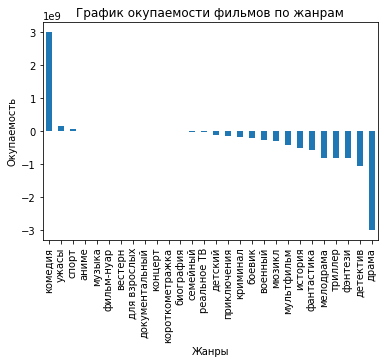

In [93]:
#построим график
paybk_pivot['sum_pay'].plot(title="График окупаемости фильмов по жанрам", kind='bar')
plt.xlabel('Жанры')
plt.ylabel('Окупаемость')

По окупаемости фильмы жанра "драма" уходят в минус, а значит не окупаются , больше всего по окупаемости занимают фильмы жанра "комедия", хоть рейтинг у них и меньше(5.99), по сумме они занимают второе место

Посмотрим теперь окупаемость по источнику государственного финансирования

In [94]:
#создадим сводную таблицу по окупаемости по источникам финансирования
paybk_pivot = data.pivot_table(index='financing_source', values="film_payback", aggfunc=["sum","mean"])
#переименнуем столбцы
paybk_pivot.columns=['sum_pay', "mean_pay"]
#отсортируем по убыванию
paybk_pivot = paybk_pivot.sort_values(by='sum_pay', ascending = False)
paybk_pivot

,sum_pay,mean_pay
financing_source,,
Фонд кино,1.706129e+09,1.523330e+07
"Министерство культуры, Фонд кино",-1.690458e+09,-8.452290e+07
Министерство культуры,-5.602598e+09,-3.710330e+07


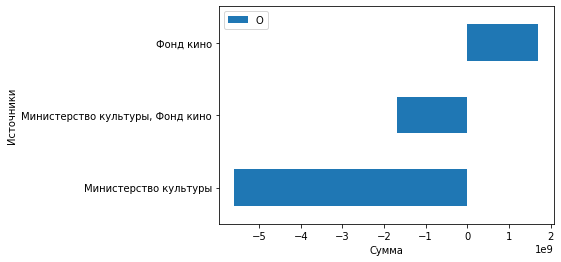

In [95]:
#сгруппируем данные, отсортируем и построим график
data.groupby("financing_source").agg("sum").sort_values(by="film_payback", ascending = True)\
.plot(y="film_payback", kind="barh")
plt.xlabel('Сумма')
plt.ylabel('Источники')
plt.legend("Окупаемость")
plt.title="График окупаемости по источнику финансирования"
plt.show()

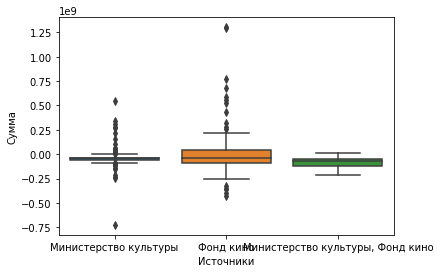

In [96]:
sns.boxplot(data= data, x='financing_source', y= "film_payback")
plt.xlabel('Источники')
plt.ylabel('Сумма')
plt.title="График окупаемости по источнику финансирования"

Вывод: Фильмы, которые находились при поддержке Фонда кино чаще окупаются. Посмотрим фильмы какого жанра среди них лидируют по окупаемости 

In [97]:
data['financing_source'] = data.loc[data['financing_source'] == "Фонд кино"]
#создадим сводную таблицу по окупаемости по источникам финансирования
fin_pivot = data.pivot_table(index='genres', values="film_payback", aggfunc="sum")
fin_pivot = fin_pivot.sort_values(by='film_payback', ascending = False).head(1)
fin_pivot

,film_payback
genres,
комедия,1.392693e+09


Среди фильмов разных жанров, которые финансирует Фонд кино, фильмы жанра "комедия" - больше всех окупаются

ВЫВОД: хоть по гос.поддержке фильмы жанра драма лидируют, они неокупаемые и имеют средний рейтинг 6.76, поэтому такие суммы неоправданные. Возможно стоит больше внимания уделить финансированию фильмов жанра "комедия"

Посмотрим на окупаемость и финансирование фильмов по режиссеру: 

- ОКУПАЕМОСТЬ 

In [98]:
#сводная таблица окупаемости по режиссерам
dir_pivot = data.pivot_table(index='director', values="film_payback", aggfunc="sum")
#переименуем столбец
dir_pivot.columns=['sum_off']
#отсортируем по убыванию
dir_pivot = dir_pivot.sort_values(by='sum_off', ascending = False).head(10)
dir_pivot

,sum_off
director,
Д.Дьяченко,1.624203e+09
О.Трофим,1.297147e+09
Н.Лебедев,7.669715e+08
"Д.Киселев, А.Першин (Ж.Крыжовников), А.Карпиловский, А.Черномазов (А.Нужный)",6.810691e+08
К.Феоктистов,5.847624e+08
А.Першин (псевдоним Ж.Крыжовников),5.524097e+08
А.Черномазов (псевдоним Алексей Нужный),5.458131e+08
Д.Шмидт,5.256702e+08
Д.Козловский,4.303369e+08


<AxesSubplot:ylabel='director'>

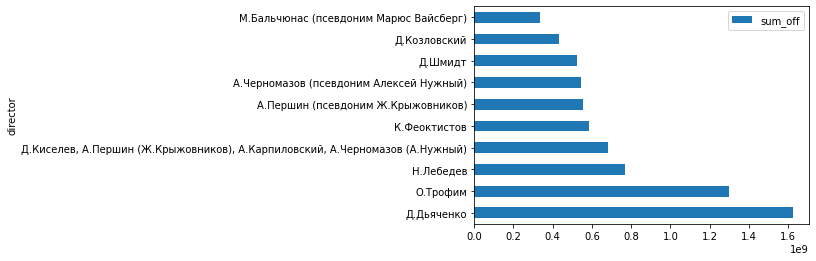

In [99]:
#построим графиик
dir_pivot.plot(kind='barh')

- СУММА ФИНАНСИРОВАНИЯ

In [101]:
data["all_gov_sup"] = data["refundable_support"].fillna(0) + data["nonrefundable_support"].fillna(0)
#сводная таблица по гос.поддержке
dir_pivot_sup = data.pivot_table(index='director', values="all_gov_sup", aggfunc="sum")
#переименуем столбец
dir_pivot_sup.columns=['sum_sup']
#отсортируем по убыванию
dir_pivot_sup = dir_pivot_sup.sort_values(by='sum_sup', ascending = False).head(10)
dir_pivot_sup

,sum_sup
director,
Н.Лебедев,442104482.0
Р.Давлетьяров,352000000.0
Д.Дьяченко,351000000.0
С.Андреасян,325000000.0
Н.Хомерики,300000000.0
В.Тодоровский,280000000.0
П.Лунгин,280000000.0
Д.Козловский,260000000.0
К.Шипенко,252000000.0


<AxesSubplot:ylabel='director'>

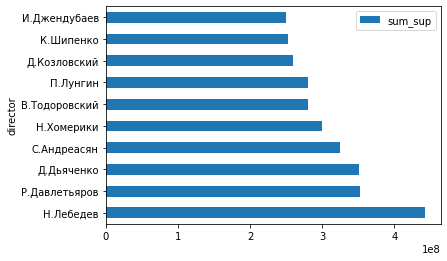

In [102]:
dir_pivot_sup.plot(kind='barh')

In [103]:
dir_pivot_sup.head(1)

,sum_sup
director,
Н.Лебедев,442104482.0


In [104]:
dir_pivot.head(1)

,sum_off
director,
Д.Дьяченко,1.624203e+09


ВЫВОД: По окупаемости выше всех фильмы режиссирования Д.Дьяченко, но по финансированию они на третьем месте, уступают фильмам Н.Лебедева, которые по финансированию лучшие, хоть по окупаемости они уступают фильмам Д.Дьяченко

### ШАГ 5. Общий вывод

1.	ОПИСАНИЕ ЦЕЛИ: Изучение рынка российского кинопроката и выявление текущих трендов. Уделим внимание фильмам, которые получили государственную поддержку. Попробуем ответить на вопрос, насколько такие фильмы интересны зрителю. 
2.	ОПИСАНИЕ ДАННЫХ: Будем работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск.
3. ЭТАПЫ ПРОЕКТА: 
- **Шаг 1.** Откроем файлы с данными и объединим их в один датафрейм
Пути к файлам:
/datasets/mkrf_movies.csv — данные о прокатных удостоверениях.
/datasets/mkrf_shows.csv — данные о прокате в российских кинотеатрах.
- **Шаг 2.** Предобработка данных
* Проверим типы данных в датафрейме и преобразуйте там, где это необходимо.
* Изучим те пропуски в датафрейме. 
* Проверим, есть ли в данных дубликаты. 
* Изучим столбцы, которые содержат категориальные значения:
* Изучим столбцы, которые хранят количественные значения. 
* Добавим новые столбцы
* Сделаем промежуточные выводы
- **Шаг 3.** Проведем исследовательский анализ данных
* Посчитаем, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируем, как эта доля менялась по годам
* Изучим, как менялась динамика проката по годам. 
* Сравним среднюю и медианную сумму сборов для каждого года. 
* Определим влияет ли возрастное ограничение аудитории на сборы фильма в прокате в период с 2015 по 2019 год 
* Сделаем промежуточные выводы
- **Шаг 4.** Исследуем фильмы, которые получили государственную поддержку
- **Шаг 5.** Напишем общий вывод
4. РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ:
- в основном с годами сумма сборов увеличивается, заметны небольшие спады в некоторые годы.
- доля фильмов с указанной информацией о прокате в кинотеатрах с 2010 по 2017 увеличивалась. Самая большая доля в 2017, но при этом само количество фильмов в этот год значительно меньше. Далее в 2018 и 2019 она заметно уменьшилась до ~0,5, но при этом эти годы содержат больше информации по фильмам и представлены полнее всего. Больше всего фильмов вышло в 2019 году, а меньше всего в 2010.
- по окупаемости лучше всего фильмы жанра "комедия", по источнику гос.финансирования - фильмы Фонда кино, по сумме гос.поддержки они занимают второе место после "драм". По рейтингу несовсем корректно смотреть, так как он не показал связи с окупаемостью или суммой гос.поддержки
-  если рассматривать фильмы по режиссеру, то наиболее окупаемы это фильмы Д.Дьяченко. По гос.поддержке лучше фильмы Н.Лебедева, но по окупаемости они ниже почти в два раза
-  для фондов, рассматривающих финансирование выпускаемых кинокартин рекомендуется уделить внимание фильмам жанра "комедия", 